In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For statistical tests
from scipy import stats
from scipy.stats import chi2_contingency
#from statsmodels.stats.multivariate import multi_normal_loglike
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
from statsmodels.discrete.discrete_model import Logit

# For imputation methods
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression

# For evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# load the dataset
indian_df= pd.read_csv('/content/indian_movies.csv')
indian_df

,index,movie_id,Rating,gross_income_doller,budget,Vote,Gross,rm_apr,rm_aug,rm_dec,...,Kannada,Malayalam,Mandarin,Marathi,Punjabi,Tamil,Telugu,Tibetan,Urdu,class
0,0,315642,7.1,5633588.0,1400000.0,15870,586028,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,403935,3.2,315609.0,13020000.0,2948,675101,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,2,884726,5.1,18662347.0,70000000.0,5392,8462027,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,1029231,5.2,4170204.0,16100000.0,19316,2191343,0,0,0,...,0,0,0,0,0,1,1,0,0,0
4,4,1198101,6.0,2986748.0,8400000.0,11592,1602466,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4021,4038,299693,7.5,373271.0,1400000.0,492,675101,0,0,0,...,0,2,0,0,0,0,0,0,0,1
4022,4039,253667,7.7,373271.0,1400000.0,217,675101,0,0,0,...,0,0,0,0,0,0,2,0,0,1
4023,4040,117111,6.2,373271.0,1400000.0,26,675101,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4024,4041,266708,5.0,373271.0,1400000.0,41,675101,0,0,0,...,0,2,0,0,0,0,0,0,0,0


In [5]:
indian_df.shape

(4026, 86)

In [6]:
indian_df.dtypes

,0
index,int64
movie_id,int64
Rating,float64
gross_income_doller,float64
budget,float64
...,...
Tamil,int64
Telugu,int64
Tibetan,int64
Urdu,int64


In [7]:
indian_df.columns

Index(['index', 'movie_id', 'Rating', 'gross_income_doller', 'budget', 'Vote',
       'Gross', 'rm_apr', 'rm_aug', 'rm_dec', 'rm_feb', 'rm_jan', 'rm_jul',
       'rm_jun', 'rm_mar', 'rm_may', 'rm_nov', 'rm_oct', 'rm_sep', 'Year',
       'Duration', 'MetaScore', 'Name', 'producer', 'producer_no',
       'pop_rank_producer', 'Producer_fb_like', 'actor_1_name', 'actor_1_no',
       'pop_rank_actor_1', 'actor_1_fb_likes', 'actor_2_name', 'actor_2_no',
       'pop_rank_actor_2', 'actor_2_fb_likes', 'actor_3_name', 'actor_3_no',
       'pop_rank_actor_3', 'actor_3_fb_likes', 'composer', 'composer_no',
       'pop_rank_composer', 'composer_fb_like', 'directors', 'director_no',
       'pop_rank_director', 'director_fb_likes', 'total_rank', 'total_fb_like',
       ' Musical', ' Mystery', 'Action', 'Adventure', 'Animation', 'Biography',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy',
       'History', 'Horror', 'Music', 'Romance', 'Sci_Fi', 'Sport', 'Thriller',
       'War

In [8]:
indian_df.drop(columns= ['index','rm_apr', 'rm_aug', 'rm_dec', 'rm_feb', 'rm_jan', 'rm_jul', 'rm_jun',
       'rm_mar', 'rm_may', 'rm_nov', 'rm_oct', 'rm_sep','gross_income_doller','Gross','MetaScore','Vote','producer', 'producer_no',
       'pop_rank_producer', 'Producer_fb_like', 'actor_1_name', 'actor_1_no',
       'pop_rank_actor_1', 'actor_1_fb_likes', 'actor_2_name', 'actor_2_no',
       'pop_rank_actor_2', 'actor_2_fb_likes', 'actor_3_name', 'actor_3_no',
       'pop_rank_actor_3', 'actor_3_fb_likes', 'composer', 'composer_no',
       'pop_rank_composer', 'composer_fb_like', 'directors', 'director_no',
       'pop_rank_director', 'director_fb_likes', 'total_rank', 'total_fb_like' ,'movie_id','Assamese','Bhojpuri','Gujarati','Tibetan', 'Urdu','class','Bengali','Mandarin','Marathi','Punjabi'], inplace=True) #dropping unnecessary columns

-->In here we mainly focus on the 'Movie Name', 'Year','Budget', 'Genre','Language of the movie', 'Rating', 'Runtime'.

-->And also we focus on Language 'English','Hindi','Telugu', 'Tamil','Malayalam','Kannada'.

In [9]:
indian_df

,Rating,budget,Year,Duration,Name,Musical,Mystery,Action,Adventure,Animation,...,Sport,Thriller,War,Western,English,Hindi,Kannada,Malayalam,Tamil,Telugu
0,7.1,1400000.0,2016,103,Wazir,0,1,1,0,0,...,0,1,0,0,0,2,0,0,0,0
1,3.2,13020000.0,2014,144,Action Jackson,0,0,1,0,0,...,0,1,0,0,0,2,0,0,0,0
2,5.1,70000000.0,2013,88,Legends of Oz: Dorothy's Return,1,0,0,1,1,...,0,0,0,0,2,0,0,0,0,0
3,5.2,16100000.0,2013,152,Krrish 3,0,0,1,0,0,...,0,0,0,1,0,2,0,0,1,1
4,6.0,8400000.0,2010,123,Kites,0,0,1,0,0,...,0,1,0,0,2,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4021,7.5,1400000.0,1994,175,Commissioner,0,0,1,0,0,...,0,1,0,0,0,0,0,2,0,0
4022,7.7,1400000.0,1991,145,Seetharamaiah Gari Manavaralu,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
4023,6.2,1400000.0,1996,140,Muqaddar,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
4024,5.0,1400000.0,1996,140,Kudumbakodathi,0,0,0,0,0,...,0,0,0,0,0,0,0,2,0,0


In [10]:
indian_df.columns = indian_df.columns.str.strip() # analyzing genre of movies

#Identify genre columns from the dataset
genre_cols = ['Musical', 'Mystery', 'Action', 'Adventure', 'Animation',
              'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family',
              'Fantasy', 'History', 'Horror', 'Music', 'Romance', 'Sci_Fi',
              'Sport', 'Thriller', 'War', 'Western']

indian_df['Genre'] = indian_df[genre_cols].apply(lambda row : ' ,'.join([g for g in genre_cols if row[g]==1]),axis=1)

#Replace blank with "No Genre"
indian_df['Genre'] = indian_df['Genre'].replace('', 'No Genre')


indian_df

,Rating,budget,Year,Duration,Name,Musical,Mystery,Action,Adventure,Animation,...,Thriller,War,Western,English,Hindi,Kannada,Malayalam,Tamil,Telugu,Genre
0,7.1,1400000.0,2016,103,Wazir,0,1,1,0,0,...,1,0,0,0,2,0,0,0,0,"Mystery ,Action ,Crime ,Drama ,Thriller"
1,3.2,13020000.0,2014,144,Action Jackson,0,0,1,0,0,...,1,0,0,0,2,0,0,0,0,"Action ,Thriller"
2,5.1,70000000.0,2013,88,Legends of Oz: Dorothy's Return,1,0,0,1,1,...,0,0,0,2,0,0,0,0,0,"Musical ,Adventure ,Animation ,Family ,Fantasy"
3,5.2,16100000.0,2013,152,Krrish 3,0,0,1,0,0,...,0,0,1,0,2,0,0,1,1,"Action ,Western"
4,6.0,8400000.0,2010,123,Kites,0,0,1,0,0,...,1,0,0,2,1,0,0,0,0,"Action ,Drama ,Romance ,Thriller"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4021,7.5,1400000.0,1994,175,Commissioner,0,0,1,0,0,...,1,0,0,0,0,0,2,0,0,"Action ,Crime ,Thriller"
4022,7.7,1400000.0,1991,145,Seetharamaiah Gari Manavaralu,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,Drama
4023,6.2,1400000.0,1996,140,Muqaddar,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,Crime
4024,5.0,1400000.0,1996,140,Kudumbakodathi,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,No Genre


In [11]:
indian_df.drop(columns=['Musical', 'Mystery', 'Action', 'Adventure', 'Animation',
       'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family',
       'Fantasy', 'History', 'Horror', 'Music', 'Romance', 'Sci_Fi', 'Sport',
       'Thriller', 'War', 'Western'],inplace=True) # since we strored genre info in a single column, we can drop these individual genre columns

In [12]:
indian_df.dtypes

,0
Rating,float64
budget,float64
Year,int64
Duration,int64
Name,object
English,int64
Hindi,int64
Kannada,int64
Malayalam,int64
Tamil,int64


In [13]:
indian_df.columns = indian_df.columns.str.strip() # analyzing language of movies

language_cols = ['English', 'Hindi', 'Kannada', 'Malayalam', 'Tamil', 'Telugu']

indian_df['Language'] = indian_df[language_cols].apply(
    lambda row: ' ,'.join([lang for lang in language_cols if row[lang] == 2]),
    axis=1
)

indian_df['Language'] = indian_df['Language'].replace('', 'Other Language')



In [14]:
indian_df

,Rating,budget,Year,Duration,Name,English,Hindi,Kannada,Malayalam,Tamil,Telugu,Genre,Language
0,7.1,1400000.0,2016,103,Wazir,0,2,0,0,0,0,"Mystery ,Action ,Crime ,Drama ,Thriller",Hindi
1,3.2,13020000.0,2014,144,Action Jackson,0,2,0,0,0,0,"Action ,Thriller",Hindi
2,5.1,70000000.0,2013,88,Legends of Oz: Dorothy's Return,2,0,0,0,0,0,"Musical ,Adventure ,Animation ,Family ,Fantasy",English
3,5.2,16100000.0,2013,152,Krrish 3,0,2,0,0,1,1,"Action ,Western",Hindi
4,6.0,8400000.0,2010,123,Kites,2,1,0,0,0,0,"Action ,Drama ,Romance ,Thriller",English
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4021,7.5,1400000.0,1994,175,Commissioner,0,0,0,2,0,0,"Action ,Crime ,Thriller",Malayalam
4022,7.7,1400000.0,1991,145,Seetharamaiah Gari Manavaralu,0,0,0,0,0,2,Drama,Telugu
4023,6.2,1400000.0,1996,140,Muqaddar,0,2,0,0,0,0,Crime,Hindi
4024,5.0,1400000.0,1996,140,Kudumbakodathi,0,0,0,2,0,0,No Genre,Malayalam


In [15]:
indian_df.drop(columns=['English', 'Hindi', 'Kannada', 'Malayalam', 'Tamil', 'Telugu'],inplace=True) #similar to genre, we can drop individual language columns
indian_df

,Rating,budget,Year,Duration,Name,Genre,Language
0,7.1,1400000.0,2016,103,Wazir,"Mystery ,Action ,Crime ,Drama ,Thriller",Hindi
1,3.2,13020000.0,2014,144,Action Jackson,"Action ,Thriller",Hindi
2,5.1,70000000.0,2013,88,Legends of Oz: Dorothy's Return,"Musical ,Adventure ,Animation ,Family ,Fantasy",English
3,5.2,16100000.0,2013,152,Krrish 3,"Action ,Western",Hindi
4,6.0,8400000.0,2010,123,Kites,"Action ,Drama ,Romance ,Thriller",English
...,...,...,...,...,...,...,...
4021,7.5,1400000.0,1994,175,Commissioner,"Action ,Crime ,Thriller",Malayalam
4022,7.7,1400000.0,1991,145,Seetharamaiah Gari Manavaralu,Drama,Telugu
4023,6.2,1400000.0,1996,140,Muqaddar,Crime,Hindi
4024,5.0,1400000.0,1996,140,Kudumbakodathi,No Genre,Malayalam


In [16]:
no_genre_count = (indian_df['Genre'] == 'No Genre').sum()
print("Movies with No Genre:", no_genre_count)

indian_df[indian_df['Genre']=='No Genre'] #since movies with no genre are very less in number, we can drop them

Movies with No Genre: 13


,Rating,budget,Year,Duration,Name,Genre,Language
901,4.7,1400000.0,2019,136,Khandaani Shafakhana,No Genre,Hindi
903,8.6,1400000.0,2019,135,Kumbalangi Nights,No Genre,Other Language
904,6.9,1400000.0,2017,119,Shubh Mangal Saavdhan,No Genre,Other Language
905,7.8,1000000.0,2013,104,Dabba,No Genre,Other Language
919,6.9,1400000.0,2018,156,Manmarziyaan,No Genre,Hindi
3475,6.6,1400000.0,1990,140,Kizhakku Vasal,No Genre,Tamil
3741,6.2,1400000.0,1992,140,Chinna Marumagal,No Genre,Tamil
3744,7.4,1400000.0,1990,145,Hosa Jeevana,No Genre,Kannada
3768,4.9,1400000.0,1992,140,Senthamizh Paattu,No Genre,Tamil
3955,6.2,1400000.0,1990,140,Dokyala Taap Nahin,No Genre,Other Language


In [17]:
indian_df = indian_df[indian_df['Genre']!= 'No Genre'].reset_index(drop=True)   #removal of 'No genre' movies
indian_df

,Rating,budget,Year,Duration,Name,Genre,Language
0,7.1,1400000.0,2016,103,Wazir,"Mystery ,Action ,Crime ,Drama ,Thriller",Hindi
1,3.2,13020000.0,2014,144,Action Jackson,"Action ,Thriller",Hindi
2,5.1,70000000.0,2013,88,Legends of Oz: Dorothy's Return,"Musical ,Adventure ,Animation ,Family ,Fantasy",English
3,5.2,16100000.0,2013,152,Krrish 3,"Action ,Western",Hindi
4,6.0,8400000.0,2010,123,Kites,"Action ,Drama ,Romance ,Thriller",English
...,...,...,...,...,...,...,...
4008,7.0,1400000.0,1990,145,Karthavyam,"Action ,Drama",Telugu
4009,7.5,1400000.0,1994,175,Commissioner,"Action ,Crime ,Thriller",Malayalam
4010,7.7,1400000.0,1991,145,Seetharamaiah Gari Manavaralu,Drama,Telugu
4011,6.2,1400000.0,1996,140,Muqaddar,Crime,Hindi


In [18]:
indian_df.dtypes

,0
Rating,float64
budget,float64
Year,int64
Duration,int64
Name,object
Genre,object
Language,object


In [19]:
indian_df.isnull().sum() #checking for missing values

,0
Rating,0
budget,0
Year,0
Duration,0
Name,0
Genre,0
Language,0


There are no missing values in this dataset


In [20]:
indian_df.dtypes

,0
Rating,float64
budget,float64
Year,int64
Duration,int64
Name,object
Genre,object
Language,object


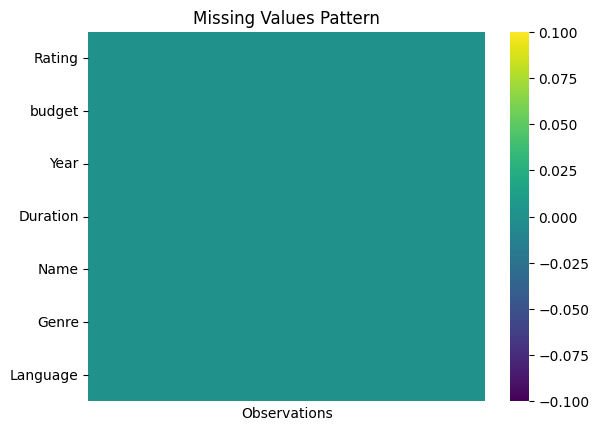

In [21]:
missing_values = indian_df.isnull()

ax = sns.heatmap(missing_values.T, cbar=True, yticklabels=True,xticklabels=False, cmap='viridis')

ax.set_title('Missing Values Pattern')
ax.set_xlabel('Observations')

plt.show() #checking missing value pattern

In [22]:
indian_df['Language'].unique()

array(['Hindi', 'English', 'Tamil', 'Other Language', 'Telugu', 'Kannada',
       'Malayalam'], dtype=object)

In [23]:
# Adding industry column

indian_df['Industry'] = indian_df['Language'].map({
    'English': 'Hollywood',
    'Hindi': 'Bollywood',
    'Tamil': 'Kollywood',
    'Telugu': 'Tollywood',
    'Kannada': 'Sandalwood',
    'Malayalam': 'Mollywood',
    'Other Language': 'Other-wood'
})
indian_df

,Rating,budget,Year,Duration,Name,Genre,Language,Industry
0,7.1,1400000.0,2016,103,Wazir,"Mystery ,Action ,Crime ,Drama ,Thriller",Hindi,Bollywood
1,3.2,13020000.0,2014,144,Action Jackson,"Action ,Thriller",Hindi,Bollywood
2,5.1,70000000.0,2013,88,Legends of Oz: Dorothy's Return,"Musical ,Adventure ,Animation ,Family ,Fantasy",English,Hollywood
3,5.2,16100000.0,2013,152,Krrish 3,"Action ,Western",Hindi,Bollywood
4,6.0,8400000.0,2010,123,Kites,"Action ,Drama ,Romance ,Thriller",English,Hollywood
...,...,...,...,...,...,...,...,...
4008,7.0,1400000.0,1990,145,Karthavyam,"Action ,Drama",Telugu,Tollywood
4009,7.5,1400000.0,1994,175,Commissioner,"Action ,Crime ,Thriller",Malayalam,Mollywood
4010,7.7,1400000.0,1991,145,Seetharamaiah Gari Manavaralu,Drama,Telugu,Tollywood
4011,6.2,1400000.0,1996,140,Muqaddar,Crime,Hindi,Bollywood


In [24]:
#converting budget into integer type
indian_df['budget'] = indian_df['budget'].astype(int)


In [25]:
indian_df = indian_df.rename(columns={'budget': 'Budget'})

#rearranging the order of the  columns  such that similar to hollywood dataset
indian_df = indian_df[['Name','Year','Genre','Budget','Duration','Rating','Language','Industry']]
indian_df

,Name,Year,Genre,Budget,Duration,Rating,Language,Industry
0,Wazir,2016,"Mystery ,Action ,Crime ,Drama ,Thriller",1400000,103,7.1,Hindi,Bollywood
1,Action Jackson,2014,"Action ,Thriller",13020000,144,3.2,Hindi,Bollywood
2,Legends of Oz: Dorothy's Return,2013,"Musical ,Adventure ,Animation ,Family ,Fantasy",70000000,88,5.1,English,Hollywood
3,Krrish 3,2013,"Action ,Western",16100000,152,5.2,Hindi,Bollywood
4,Kites,2010,"Action ,Drama ,Romance ,Thriller",8400000,123,6.0,English,Hollywood
...,...,...,...,...,...,...,...,...
4008,Karthavyam,1990,"Action ,Drama",1400000,145,7.0,Telugu,Tollywood
4009,Commissioner,1994,"Action ,Crime ,Thriller",1400000,175,7.5,Malayalam,Mollywood
4010,Seetharamaiah Gari Manavaralu,1991,Drama,1400000,145,7.7,Telugu,Tollywood
4011,Muqaddar,1996,Crime,1400000,140,6.2,Hindi,Bollywood


In [26]:
#checking for duplicates
indian_df.duplicated().any()

np.True_

In [27]:
indian_df['Name'].duplicated().sum()


np.int64(238)

In [28]:
#displaying duplicate movie names
indian_df[indian_df['Name'].duplicated(keep=False)].sort_values(by='Name')


,Name,Year,Genre,Budget,Duration,Rating,Language,Industry
605,100 Days of Love,2015,"Comedy ,Romance",560000,153,6.6,Malayalam,Mollywood
1446,100 Days of Love,2015,"Comedy ,Romance",560000,153,6.6,Malayalam,Mollywood
623,1920 London,2016,"Mystery ,Horror",1400000,120,4.1,Hindi,Bollywood
1014,1920 London,2016,"Mystery ,Horror",1400000,120,4.1,Hindi,Bollywood
564,1920: Evil Returns,2012,"Drama ,Horror ,Romance",1400000,124,4.8,Hindi,Bollywood
...,...,...,...,...,...,...,...,...
2723,Yogi,2009,Drama,1400000,144,6.8,Tamil,Kollywood
1202,Zila Ghaziabad,2013,"Action ,Crime ,Thriller",1400000,142,3.5,Hindi,Bollywood
634,Zila Ghaziabad,2013,"Action ,Crime ,Thriller",1400000,142,3.5,Hindi,Bollywood
1242,Zulfiqar,2016,"Crime ,Drama ,Thriller",1400000,139,5.7,Other Language,Other-wood


In [29]:
#dropping duplicate movie names
indian_df = indian_df.drop_duplicates(subset='Name', keep='first')
indian_df


,Name,Year,Genre,Budget,Duration,Rating,Language,Industry
0,Wazir,2016,"Mystery ,Action ,Crime ,Drama ,Thriller",1400000,103,7.1,Hindi,Bollywood
1,Action Jackson,2014,"Action ,Thriller",13020000,144,3.2,Hindi,Bollywood
2,Legends of Oz: Dorothy's Return,2013,"Musical ,Adventure ,Animation ,Family ,Fantasy",70000000,88,5.1,English,Hollywood
3,Krrish 3,2013,"Action ,Western",16100000,152,5.2,Hindi,Bollywood
4,Kites,2010,"Action ,Drama ,Romance ,Thriller",8400000,123,6.0,English,Hollywood
...,...,...,...,...,...,...,...,...
4008,Karthavyam,1990,"Action ,Drama",1400000,145,7.0,Telugu,Tollywood
4009,Commissioner,1994,"Action ,Crime ,Thriller",1400000,175,7.5,Malayalam,Mollywood
4010,Seetharamaiah Gari Manavaralu,1991,Drama,1400000,145,7.7,Telugu,Tollywood
4011,Muqaddar,1996,Crime,1400000,140,6.2,Hindi,Bollywood


In [30]:
#rechecking for duplicates
indian_df.duplicated().any()

np.False_

In [31]:
#counting number of movies in each language
list = ['Hindi', 'English', 'Tamil', 'Other Language', 'Telugu', 'Kannada',
       'Malayalam']

for i in list:
    count = len(indian_df[indian_df['Language'] == str(i)])
    print(f"Number of {i}  movies are {count}")

Number of Hindi  movies are 1888
Number of English  movies are 148
Number of Tamil  movies are 551
Number of Other Language  movies are 397
Number of Telugu  movies are 411
Number of Kannada  movies are 75
Number of Malayalam  movies are 305


In [33]:
#saving the modified dataset
indian_df.to_csv('modified_indian_movies.csv', index=False)